# Irrational rotations: trig functions of irrational numbers evolving through time

Pick an irrational number `alpha`. Walk around a circle in steps of `alpha` turns: point `n` sits at angle `2*pi*(n*alpha mod 1)`. Connect consecutive points with a chord and let `n` grow.

Because `alpha` is irrational, `n*alpha mod 1` never repeats and — by Weyl's equidistribution theorem — becomes dense on the circle. The chords sweep out a rose that never closes and keeps filling in finer detail as `n` grows. A **rational** `alpha`, by contrast, snaps shut into a plain old star polygon after finitely many points and just retraces itself forever after.

Three views of the same idea:
1. A static gallery of roses for a few irrationals (and one rational control, for contrast)
2. One of them animated, growing chord by chord
3. The continuous version — Lissajous curves with an irrational frequency ratio, which likewise never close

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from PIL import Image
from io import BytesIO
from IPython.display import Image as IPImage

PHI = (1 + 5 ** 0.5) / 2  # golden ratio

## The rose: connect the dots at `n * alpha` turns

In [2]:
def rose_xy(alpha, n_points):
    """Unit-circle points at angle 2*pi*(n*alpha mod 1) for n = 0..n_points-1."""
    n = np.arange(n_points)
    angles = 2 * np.pi * np.mod(n * alpha, 1.0)
    return np.cos(angles), np.sin(angles)

def rose_segments(alpha, n_points):
    """Line segments connecting consecutive rose points, for a LineCollection."""
    x, y = rose_xy(alpha, n_points)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    return np.concatenate([points[:-1], points[1:]], axis=1)

def plot_rose(alpha, n_points, ax, title, cmap="viridis"):
    segments = rose_segments(alpha, n_points)
    lc = LineCollection(segments, cmap=cmap, linewidth=0.6)
    lc.set_array(np.arange(len(segments)))  # colored by step = "time"
    ax.add_collection(lc)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    return lc

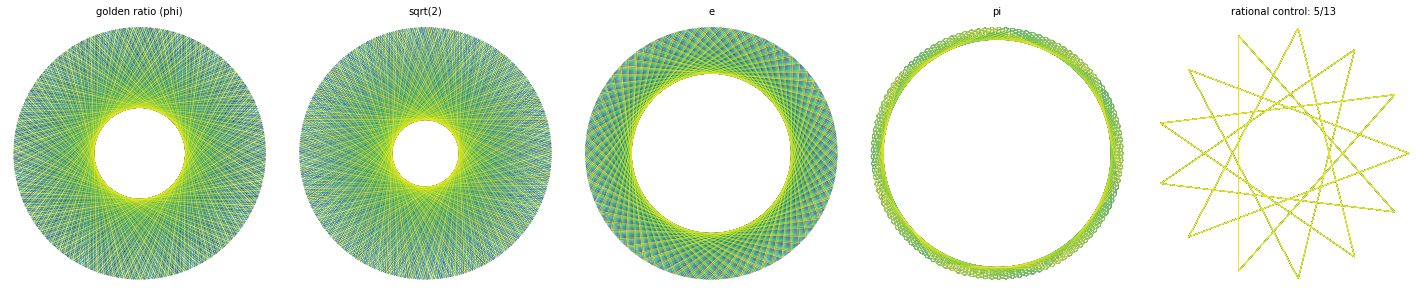

In [3]:
alphas = {
    "golden ratio (phi)": PHI % 1,
    "sqrt(2)": np.sqrt(2) % 1,
    "e": np.e % 1,
    "pi": np.pi % 1,
    "rational control: 5/13": 5 / 13,
}

fig, axes = plt.subplots(1, len(alphas), figsize=(4 * len(alphas), 4))
for ax, (name, alpha) in zip(axes, alphas.items()):
    plot_rose(alpha, 600, ax, name)
plt.tight_layout()
plt.savefig("irrational_roses.png", dpi=150, facecolor="white")
plt.show()

Four of these keep revealing new detail no matter how far out you go — 600 chords in, they still haven't repeated a single line. The rational control (5/13 of a turn) closes into a clean 13-pointed star and just overdraws the same 13 lines for the rest of the run. Look closely, though: phi's rose fills in evenly almost right away, while pi's stays a thin ring for a while before it starts crossing itself. That's not a rendering fluke -- pi is very well approximated by the fraction 22/7, so for the first several hundred steps it behaves almost like a rational number with denominator 7, tracing something close to a 7-pointed star before the tiny leftover error accumulates enough to fill in. The golden ratio is the opposite extreme: continued-fraction theory calls it the *most irrational* number, the one worst-approximated by any fraction, which is exactly why its rose fills in fastest and most evenly of the four -- and why nature uses that same angle for packing sunflower seeds with no gaps.

## Watch it grow: the rose forming, chord by chord

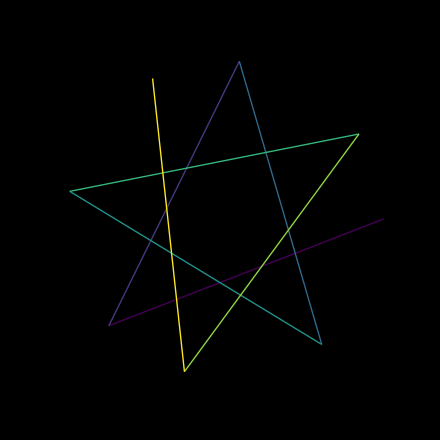

In [4]:
def render_rose_frame(alpha, n_points, size=4, dpi=110, cmap="viridis"):
    segments = rose_segments(alpha, n_points)
    fig, ax = plt.subplots(figsize=(size, size), dpi=dpi)
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")
    lc = LineCollection(segments, cmap=cmap, linewidth=0.9)
    lc.set_array(np.arange(len(segments)))
    ax.add_collection(lc)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.axis("off")
    buf = BytesIO()
    fig.savefig(buf, format="png", facecolor="black")
    buf.seek(0)
    frame = Image.open(buf).convert("RGB")
    plt.close(fig)
    return frame

alpha_hero = PHI % 1  # the golden angle -- the iconic case (phyllotaxis, sunflower seed heads)
growth_steps = np.linspace(8, 500, 40, dtype=int)
frames = [render_rose_frame(alpha_hero, n) for n in growth_steps]

gif_path = "golden_angle_rose.gif"
frames[0].save(gif_path, save_all=True, append_images=frames[1:], duration=90, loop=0)
IPImage(filename=gif_path)

## The continuous version: Lissajous curves with an irrational frequency ratio

Same idea, continuous instead of discrete: `x(t) = sin(t)`, `y(t) = sin(alpha*t + phase)`. When `alpha` is rational this is the classic closed Lissajous figure. When `alpha` is irrational the trajectory never closes and becomes dense in the square -- same equidistribution argument, now on two phases instead of one.

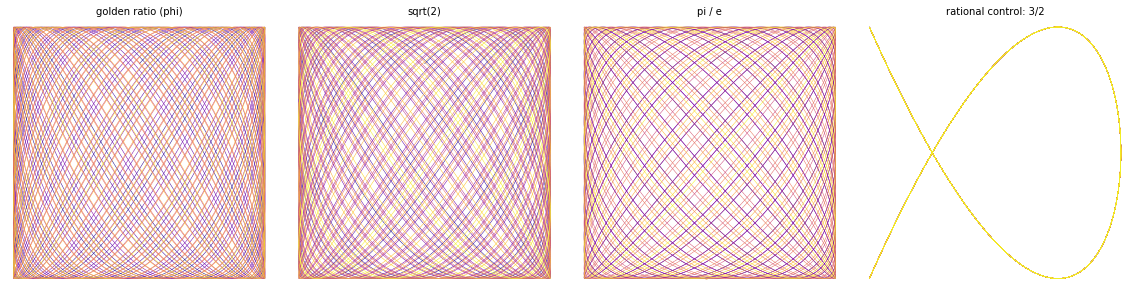

In [5]:
def lissajous_xy(alpha, t, phase=np.pi / 4):
    return np.sin(t), np.sin(alpha * t + phase)

lissajous_alphas = {
    "golden ratio (phi)": PHI,
    "sqrt(2)": np.sqrt(2),
    "pi / e": np.pi / np.e,
    "rational control: 3/2": 1.5,
}

t = np.linspace(0, 400, 20_000)
fig, axes = plt.subplots(1, len(lissajous_alphas), figsize=(4 * len(lissajous_alphas), 4))
for ax, (name, alpha) in zip(axes, lissajous_alphas.items()):
    x, y = lissajous_xy(alpha, t)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap="plasma", linewidth=0.5)
    lc.set_array(t[:-1])
    ax.add_collection(lc)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.savefig("lissajous_irrational.png", dpi=150, facecolor="white")
plt.show()

## Takeaways

- Both pictures are the same theorem wearing different clothes: **irrational multiples never fall into a repeating cycle**, so any trig function driven by `n * alpha` (discrete) or `alpha * t` (continuous) keeps exploring new territory forever instead of retracing a closed loop.
- The golden angle (`phi mod 1` of a turn, ~137.5 degrees) is the same constant behind sunflower seed heads and pinecones -- nature uses it for exactly this "never overlap, always fill in the gaps" property.
- Rational ratios are the special, measure-zero case: only a rational `alpha` gives you a closed star polygon or a classic closed Lissajous figure. Almost every real number is irrational, so "never closes" is actually the generic, typical behavior -- closed curves are the exception.